In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torch.distributions.beta import Beta
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Normalize to [-1, 1]
normalize = transforms.Normalize((0.5, 0.5, 0.5),
                                 (0.5, 0.5, 0.5))

# Raw transform
transform_raw = transforms.Compose([
    transforms.ToTensor(),
    normalize
])

# Individual augmentations
transform_hflip = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize
])

transform_crop = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    normalize
])

transform_color = transforms.Compose([
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    normalize
])

In [ ]:
def get_loaders(transform_train, batch_size=512):

    trainset = torchvision.datasets.CIFAR10(
        root='./data',
        train=True,
        download=True,
        transform=transform_train
    )

    testset = torchvision.datasets.CIFAR10(
        root='./data',
        train=False,
        download=True,
        transform=transform_raw
    )

    trainloader = DataLoader(trainset, batch_size=batch_size,
                             shuffle=True, num_workers=2)

    testloader = DataLoader(testset, batch_size=batch_size,
                            shuffle=False, num_workers=2)

    return trainloader, testloader

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
def mixup_data(x, y, alpha=1.0):
    if alpha > 0:
        lam = Beta(alpha, alpha).sample().item()
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [ ]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item()
            _, pred = outputs.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()

    acc = 100. * correct / total
    return total_loss / len(loader), acc

In [ ]:
import matplotlib.pyplot as plt

def train_model(mode="raw", alpha=1.0, epochs=20):
    if mode == "raw":
        transform_train = transform_raw

    elif mode == "RandomHorizontalFlip":
        transform_train = transform_hflip

    elif mode == "RandomCrop":
        transform_train = transform_crop

    elif mode == "ColorJitter":
        transform_train = transform_color

    elif mode == "mixup":
        transform_train = transform_raw  # mixup works on raw tensors

    else:
        raise ValueError(f"Unknown mode: {mode}")

    trainloader, testloader = get_loaders(transform_train)


    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for x, y in trainloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            if mode == "mixup":
                x, y_a, y_b, lam = mixup_data(x, y, alpha)
                outputs = model(x)
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            else:
                outputs = model(x)
                loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(trainloader)
        val_loss, val_acc = evaluate(model, testloader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"{mode.upper()} Epoch {epoch+1}/{epochs} "
              f"Train Loss: {train_loss:.4f} "
              f"Val Acc: {val_acc:.2f}%")

    # 🔥 SINGLE COMBINED PLOT
    fig, ax1 = plt.subplots()

    ax1.plot(train_losses, label="Train Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Train Loss")

    ax2 = ax1.twinx()
    ax2.plot(val_accs, label="Val Accuracy")
    ax2.set_ylabel("Validation Accuracy (%)")

    # combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.title(f"Training Curve ({mode})")
    plt.show()

    return model, train_losses, val_losses, val_accs[-1]


=== RAW TRAINING ===
RAW Epoch 1/20 Train Loss: 1.3315 Val Acc: 61.83%
RAW Epoch 2/20 Train Loss: 0.9363 Val Acc: 65.90%
RAW Epoch 3/20 Train Loss: 0.7657 Val Acc: 69.18%
RAW Epoch 4/20 Train Loss: 0.6453 Val Acc: 68.77%
RAW Epoch 5/20 Train Loss: 0.5447 Val Acc: 69.87%
RAW Epoch 6/20 Train Loss: 0.4527 Val Acc: 69.16%
RAW Epoch 7/20 Train Loss: 0.3735 Val Acc: 69.21%
RAW Epoch 8/20 Train Loss: 0.3018 Val Acc: 69.90%
RAW Epoch 9/20 Train Loss: 0.2400 Val Acc: 69.55%
RAW Epoch 10/20 Train Loss: 0.1898 Val Acc: 70.30%
RAW Epoch 11/20 Train Loss: 0.1484 Val Acc: 69.74%
RAW Epoch 12/20 Train Loss: 0.1093 Val Acc: 70.49%
RAW Epoch 13/20 Train Loss: 0.0840 Val Acc: 68.59%
RAW Epoch 14/20 Train Loss: 0.0641 Val Acc: 70.97%
RAW Epoch 15/20 Train Loss: 0.0498 Val Acc: 69.73%
RAW Epoch 16/20 Train Loss: 0.0356 Val Acc: 70.34%
RAW Epoch 17/20 Train Loss: 0.0284 Val Acc: 70.38%
RAW Epoch 18/20 Train Loss: 0.0221 Val Acc: 70.49%
RAW Epoch 19/20 Train Loss: 0.0172 Val Acc: 70.80%
RAW Epoch 20/20 Tr

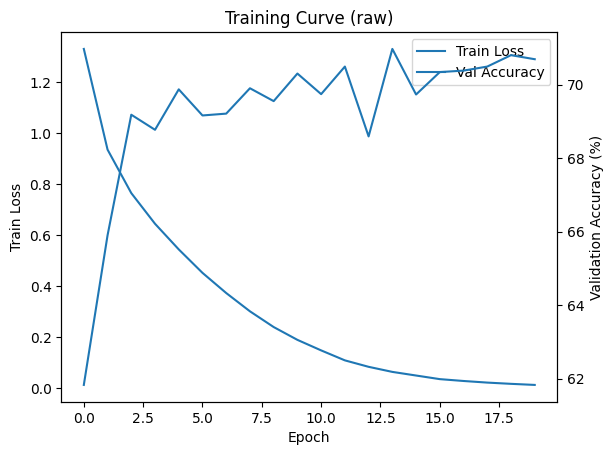


=== TRADITIONAL AUG ===
RANDOMHORIZONTALFLIP Epoch 1/20 Train Loss: 1.3518 Val Acc: 62.15%
RANDOMHORIZONTALFLIP Epoch 2/20 Train Loss: 0.9567 Val Acc: 66.58%
RANDOMHORIZONTALFLIP Epoch 3/20 Train Loss: 0.8222 Val Acc: 68.71%
RANDOMHORIZONTALFLIP Epoch 4/20 Train Loss: 0.7381 Val Acc: 71.18%
RANDOMHORIZONTALFLIP Epoch 5/20 Train Loss: 0.6679 Val Acc: 73.08%
RANDOMHORIZONTALFLIP Epoch 6/20 Train Loss: 0.6152 Val Acc: 70.91%
RANDOMHORIZONTALFLIP Epoch 7/20 Train Loss: 0.5617 Val Acc: 73.71%
RANDOMHORIZONTALFLIP Epoch 8/20 Train Loss: 0.5141 Val Acc: 72.75%
RANDOMHORIZONTALFLIP Epoch 9/20 Train Loss: 0.4739 Val Acc: 73.72%
RANDOMHORIZONTALFLIP Epoch 10/20 Train Loss: 0.4392 Val Acc: 73.74%
RANDOMHORIZONTALFLIP Epoch 11/20 Train Loss: 0.3987 Val Acc: 73.78%
RANDOMHORIZONTALFLIP Epoch 12/20 Train Loss: 0.3731 Val Acc: 74.30%
RANDOMHORIZONTALFLIP Epoch 13/20 Train Loss: 0.3406 Val Acc: 72.13%
RANDOMHORIZONTALFLIP Epoch 14/20 Train Loss: 0.3092 Val Acc: 74.04%
RANDOMHORIZONTALFLIP Epoch 15/20

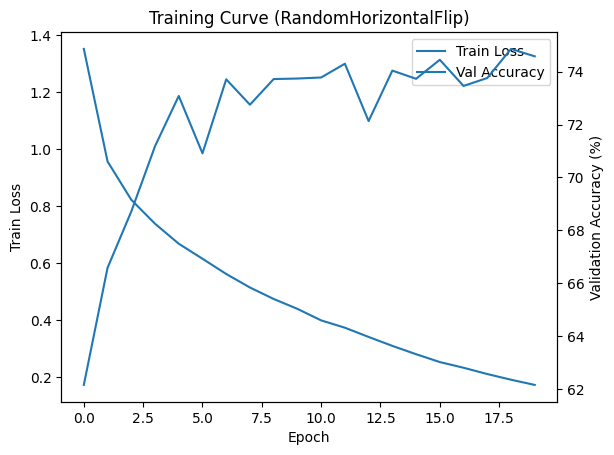


=== TRADITIONAL AUG ===
RANDOMCROP Epoch 1/20 Train Loss: 1.5282 Val Acc: 58.39%
RANDOMCROP Epoch 2/20 Train Loss: 1.1910 Val Acc: 63.43%
RANDOMCROP Epoch 3/20 Train Loss: 1.0708 Val Acc: 65.61%
RANDOMCROP Epoch 4/20 Train Loss: 0.9899 Val Acc: 68.36%
RANDOMCROP Epoch 5/20 Train Loss: 0.9365 Val Acc: 67.34%
RANDOMCROP Epoch 6/20 Train Loss: 0.8928 Val Acc: 70.82%
RANDOMCROP Epoch 7/20 Train Loss: 0.8515 Val Acc: 70.80%
RANDOMCROP Epoch 8/20 Train Loss: 0.8202 Val Acc: 72.55%
RANDOMCROP Epoch 9/20 Train Loss: 0.7922 Val Acc: 73.98%
RANDOMCROP Epoch 10/20 Train Loss: 0.7684 Val Acc: 74.71%
RANDOMCROP Epoch 11/20 Train Loss: 0.7508 Val Acc: 73.42%
RANDOMCROP Epoch 12/20 Train Loss: 0.7292 Val Acc: 75.08%
RANDOMCROP Epoch 13/20 Train Loss: 0.7096 Val Acc: 75.09%
RANDOMCROP Epoch 14/20 Train Loss: 0.6901 Val Acc: 75.31%
RANDOMCROP Epoch 15/20 Train Loss: 0.6721 Val Acc: 76.10%
RANDOMCROP Epoch 16/20 Train Loss: 0.6600 Val Acc: 76.25%
RANDOMCROP Epoch 17/20 Train Loss: 0.6413 Val Acc: 76.24

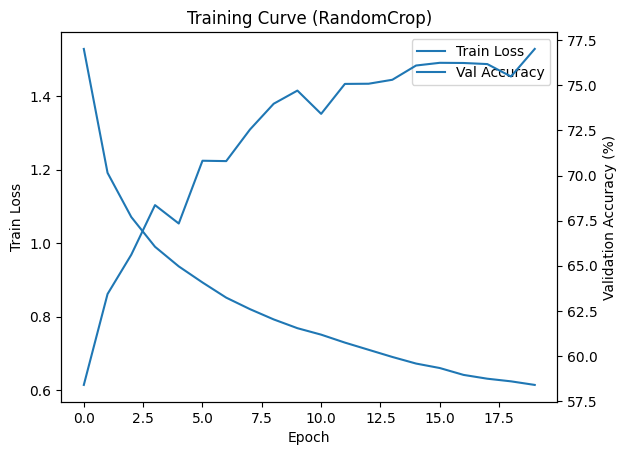


=== TRADITIONAL AUG ===
COLORJITTER Epoch 1/20 Train Loss: 1.4066 Val Acc: 58.91%
COLORJITTER Epoch 2/20 Train Loss: 1.0137 Val Acc: 66.53%
COLORJITTER Epoch 3/20 Train Loss: 0.8561 Val Acc: 68.61%
COLORJITTER Epoch 4/20 Train Loss: 0.7441 Val Acc: 67.52%
COLORJITTER Epoch 5/20 Train Loss: 0.6507 Val Acc: 69.50%
COLORJITTER Epoch 6/20 Train Loss: 0.5719 Val Acc: 67.80%
COLORJITTER Epoch 7/20 Train Loss: 0.4997 Val Acc: 71.31%
COLORJITTER Epoch 8/20 Train Loss: 0.4394 Val Acc: 71.00%
COLORJITTER Epoch 9/20 Train Loss: 0.3806 Val Acc: 67.22%
COLORJITTER Epoch 10/20 Train Loss: 0.3267 Val Acc: 69.52%
COLORJITTER Epoch 11/20 Train Loss: 0.2754 Val Acc: 69.65%
COLORJITTER Epoch 12/20 Train Loss: 0.2393 Val Acc: 69.66%
COLORJITTER Epoch 13/20 Train Loss: 0.2062 Val Acc: 68.81%
COLORJITTER Epoch 14/20 Train Loss: 0.1775 Val Acc: 69.08%
COLORJITTER Epoch 15/20 Train Loss: 0.1517 Val Acc: 69.33%
COLORJITTER Epoch 16/20 Train Loss: 0.1270 Val Acc: 69.44%
COLORJITTER Epoch 17/20 Train Loss: 0.11

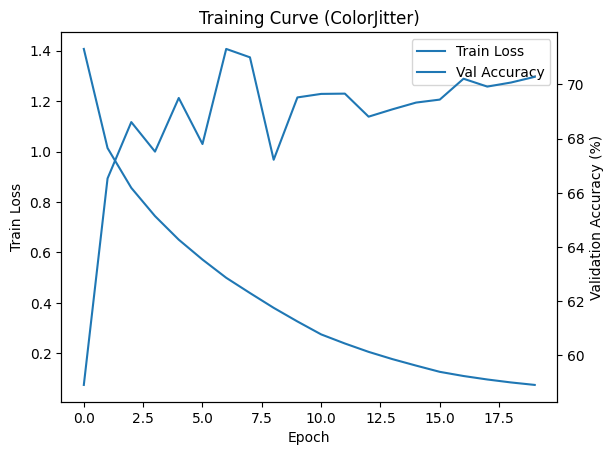


=== MIXUP (alpha=0.4) ===
MIXUP Epoch 1/20 Train Loss: 1.6097 Val Acc: 60.82%
MIXUP Epoch 2/20 Train Loss: 1.3058 Val Acc: 63.67%
MIXUP Epoch 3/20 Train Loss: 1.3015 Val Acc: 63.99%
MIXUP Epoch 4/20 Train Loss: 1.1857 Val Acc: 70.79%
MIXUP Epoch 5/20 Train Loss: 1.1676 Val Acc: 70.30%
MIXUP Epoch 6/20 Train Loss: 1.0369 Val Acc: 71.01%
MIXUP Epoch 7/20 Train Loss: 1.0256 Val Acc: 70.21%
MIXUP Epoch 8/20 Train Loss: 1.0552 Val Acc: 69.63%
MIXUP Epoch 9/20 Train Loss: 0.9578 Val Acc: 70.74%
MIXUP Epoch 10/20 Train Loss: 0.9652 Val Acc: 71.50%
MIXUP Epoch 11/20 Train Loss: 1.0151 Val Acc: 69.49%
MIXUP Epoch 12/20 Train Loss: 0.9593 Val Acc: 71.29%
MIXUP Epoch 13/20 Train Loss: 0.9316 Val Acc: 71.77%
MIXUP Epoch 14/20 Train Loss: 0.9191 Val Acc: 70.16%
MIXUP Epoch 15/20 Train Loss: 0.8693 Val Acc: 70.98%
MIXUP Epoch 16/20 Train Loss: 0.8402 Val Acc: 70.57%
MIXUP Epoch 17/20 Train Loss: 0.8361 Val Acc: 71.48%
MIXUP Epoch 18/20 Train Loss: 0.9258 Val Acc: 70.45%
MIXUP Epoch 19/20 Train Loss

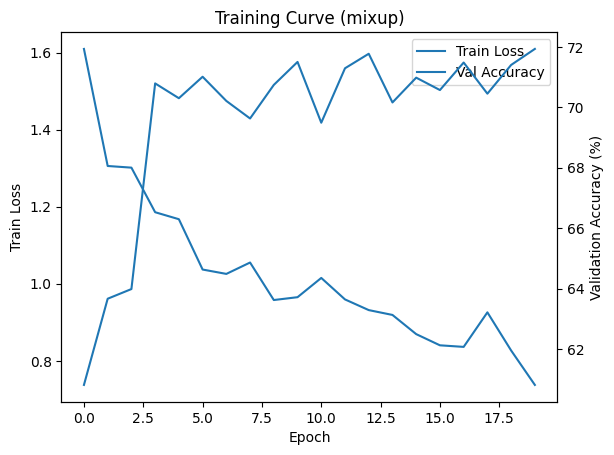

In [ ]:
results = {}

print("\n=== RAW TRAINING ===")
results["raw"] = train_model("raw")

print("\n=== TRADITIONAL AUG ===")
results["RandomHorizontalFlip"] = train_model("RandomHorizontalFlip")


print("\n=== TRADITIONAL AUG ===")
results["RandomCrop"] = train_model("RandomCrop")


print("\n=== TRADITIONAL AUG ===")
results["ColorJitter"] = train_model("ColorJitter")

print("\n=== MIXUP (alpha=0.4) ===")
results["mixup"] = train_model("mixup", alpha=0.4)

MIXUP Epoch 1/20 Train Loss: 1.4347 Val Acc: 58.18%
MIXUP Epoch 2/20 Train Loss: 1.0868 Val Acc: 63.86%
MIXUP Epoch 3/20 Train Loss: 0.9911 Val Acc: 70.13%
MIXUP Epoch 4/20 Train Loss: 0.8451 Val Acc: 69.50%
MIXUP Epoch 5/20 Train Loss: 0.8413 Val Acc: 69.46%
MIXUP Epoch 6/20 Train Loss: 0.7744 Val Acc: 70.56%
MIXUP Epoch 7/20 Train Loss: 0.7674 Val Acc: 70.17%
MIXUP Epoch 8/20 Train Loss: 0.7396 Val Acc: 68.14%
MIXUP Epoch 9/20 Train Loss: 0.6166 Val Acc: 69.82%
MIXUP Epoch 10/20 Train Loss: 0.6065 Val Acc: 69.00%
MIXUP Epoch 11/20 Train Loss: 0.5486 Val Acc: 70.00%
MIXUP Epoch 12/20 Train Loss: 0.5627 Val Acc: 69.99%
MIXUP Epoch 13/20 Train Loss: 0.5004 Val Acc: 70.62%
MIXUP Epoch 14/20 Train Loss: 0.4560 Val Acc: 68.45%
MIXUP Epoch 15/20 Train Loss: 0.4994 Val Acc: 71.28%
MIXUP Epoch 16/20 Train Loss: 0.4586 Val Acc: 70.53%
MIXUP Epoch 17/20 Train Loss: 0.4009 Val Acc: 70.91%
MIXUP Epoch 18/20 Train Loss: 0.3690 Val Acc: 69.86%
MIXUP Epoch 19/20 Train Loss: 0.4317 Val Acc: 70.18%
MI

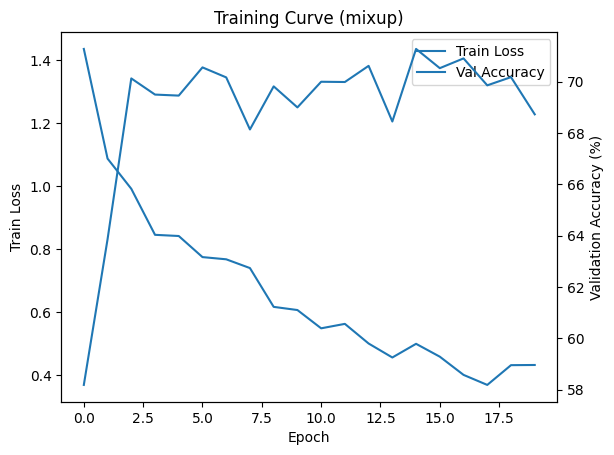

MIXUP Epoch 1/20 Train Loss: 1.4427 Val Acc: 63.53%
MIXUP Epoch 2/20 Train Loss: 1.1743 Val Acc: 67.02%
MIXUP Epoch 3/20 Train Loss: 1.0542 Val Acc: 68.35%
MIXUP Epoch 4/20 Train Loss: 1.0403 Val Acc: 70.92%
MIXUP Epoch 5/20 Train Loss: 0.9211 Val Acc: 70.62%
MIXUP Epoch 6/20 Train Loss: 0.9249 Val Acc: 68.80%
MIXUP Epoch 7/20 Train Loss: 0.8556 Val Acc: 70.14%
MIXUP Epoch 8/20 Train Loss: 0.8122 Val Acc: 70.15%
MIXUP Epoch 9/20 Train Loss: 0.8444 Val Acc: 69.15%
MIXUP Epoch 10/20 Train Loss: 0.6462 Val Acc: 69.73%
MIXUP Epoch 11/20 Train Loss: 0.8243 Val Acc: 70.27%
MIXUP Epoch 12/20 Train Loss: 0.6711 Val Acc: 71.09%
MIXUP Epoch 13/20 Train Loss: 0.6718 Val Acc: 71.55%
MIXUP Epoch 14/20 Train Loss: 0.7318 Val Acc: 70.40%
MIXUP Epoch 15/20 Train Loss: 0.6310 Val Acc: 71.03%
MIXUP Epoch 16/20 Train Loss: 0.5938 Val Acc: 71.72%
MIXUP Epoch 17/20 Train Loss: 0.5177 Val Acc: 71.80%
MIXUP Epoch 18/20 Train Loss: 0.5807 Val Acc: 72.00%
MIXUP Epoch 19/20 Train Loss: 0.5694 Val Acc: 71.13%
MI

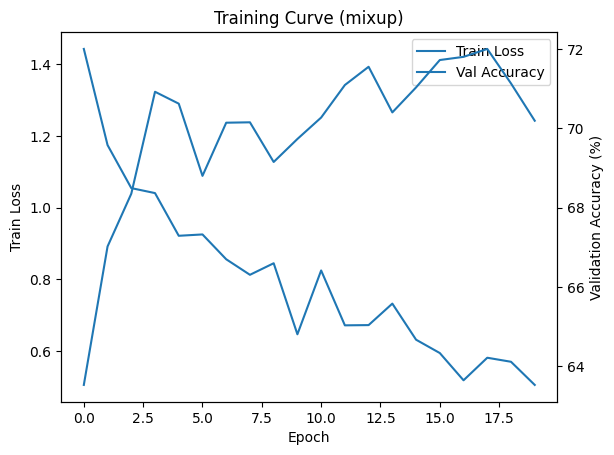

MIXUP Epoch 1/20 Train Loss: 1.6744 Val Acc: 61.61%
MIXUP Epoch 2/20 Train Loss: 1.4518 Val Acc: 65.35%
MIXUP Epoch 3/20 Train Loss: 1.3844 Val Acc: 69.49%
MIXUP Epoch 4/20 Train Loss: 1.3203 Val Acc: 68.92%
MIXUP Epoch 5/20 Train Loss: 1.3074 Val Acc: 71.26%
MIXUP Epoch 6/20 Train Loss: 1.2859 Val Acc: 70.06%
MIXUP Epoch 7/20 Train Loss: 1.2630 Val Acc: 71.09%
MIXUP Epoch 8/20 Train Loss: 1.2293 Val Acc: 72.45%
MIXUP Epoch 9/20 Train Loss: 1.1495 Val Acc: 72.39%
MIXUP Epoch 10/20 Train Loss: 1.2044 Val Acc: 73.15%
MIXUP Epoch 11/20 Train Loss: 1.1480 Val Acc: 71.97%
MIXUP Epoch 12/20 Train Loss: 1.0890 Val Acc: 72.85%
MIXUP Epoch 13/20 Train Loss: 1.0728 Val Acc: 71.44%
MIXUP Epoch 14/20 Train Loss: 1.1301 Val Acc: 72.77%
MIXUP Epoch 15/20 Train Loss: 1.1027 Val Acc: 72.68%
MIXUP Epoch 16/20 Train Loss: 1.0623 Val Acc: 72.94%
MIXUP Epoch 17/20 Train Loss: 1.0918 Val Acc: 71.37%
MIXUP Epoch 18/20 Train Loss: 1.0787 Val Acc: 73.15%
MIXUP Epoch 19/20 Train Loss: 1.0813 Val Acc: 71.67%
MI

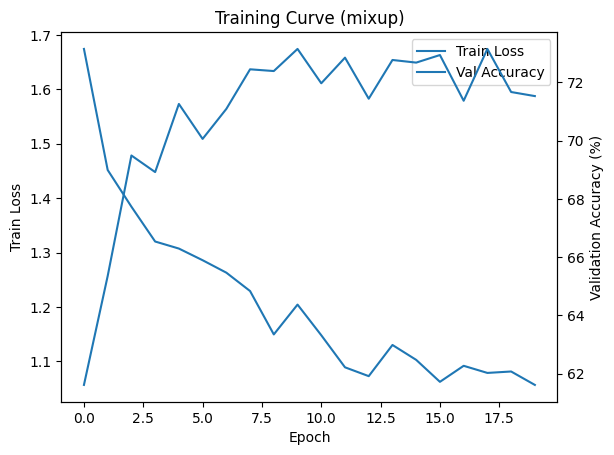

(SimpleCNN(
   (features): Sequential(
     (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU()
     (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (6): ReLU()
     (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (classifier): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=4096, out_features=128, bias=True)
     (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (3): ReLU()
     (4): Linear(in_features=128, out_features=10, bias=True)
   )
 ),
 [1.6744151845270274,
  1.4518338709461445,
  1.3843516567531897,
  1.3203126161682361,
  1.30736073669122

In [ ]:
train_model("mixup", alpha=0.1 , epochs=20)
train_model("mixup", alpha=0.2 , epochs=20)
train_model("mixup", alpha=0.8 , epochs=20)

In [ ]:
train_model("mixup", alpha=0.2 , epochs=30)

MIXUP Epoch 1/30 Train Loss: 1.7298 Val Acc: 55.84%
MIXUP Epoch 2/30 Train Loss: 1.4658 Val Acc: 63.47%
MIXUP Epoch 3/30 Train Loss: 1.4212 Val Acc: 65.08%
MIXUP Epoch 4/30 Train Loss: 1.3263 Val Acc: 66.71%
MIXUP Epoch 5/30 Train Loss: 1.3375 Val Acc: 68.02%
MIXUP Epoch 6/30 Train Loss: 1.2157 Val Acc: 68.26%
MIXUP Epoch 7/30 Train Loss: 1.2156 Val Acc: 69.30%
MIXUP Epoch 8/30 Train Loss: 1.1876 Val Acc: 70.97%
MIXUP Epoch 9/30 Train Loss: 1.1719 Val Acc: 71.82%
MIXUP Epoch 10/30 Train Loss: 1.2275 Val Acc: 73.53%
MIXUP Epoch 11/30 Train Loss: 1.1893 Val Acc: 73.69%
MIXUP Epoch 12/30 Train Loss: 1.1021 Val Acc: 74.69%
MIXUP Epoch 13/30 Train Loss: 1.1762 Val Acc: 75.08%
MIXUP Epoch 14/30 Train Loss: 1.1629 Val Acc: 74.52%
MIXUP Epoch 15/30 Train Loss: 1.1015 Val Acc: 75.52%
MIXUP Epoch 16/30 Train Loss: 1.1223 Val Acc: 75.76%
MIXUP Epoch 17/30 Train Loss: 1.0650 Val Acc: 75.32%
MIXUP Epoch 18/30 Train Loss: 1.0464 Val Acc: 76.13%
MIXUP Epoch 19/30 Train Loss: 1.0852 Val Acc: 75.75%
MI

(SimpleCNN(
   (features): Sequential(
     (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU()
     (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (6): ReLU()
     (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (classifier): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=4096, out_features=128, bias=True)
     (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (3): ReLU()
     (4): Linear(in_features=128, out_features=10, bias=True)
   )
 ),
 [1.7298408552091948,
  1.4657870129663118,
  1.4211998861663195,
  1.326343649504136,
  1.337486999983690

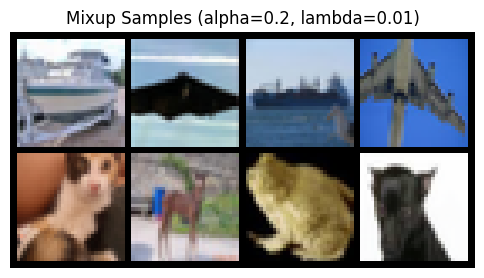

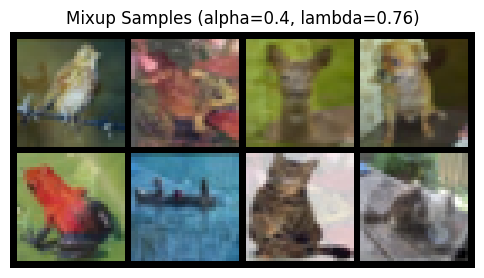

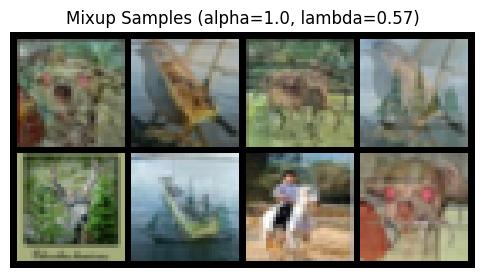

In [ ]:
def visualize_mixup(alpha=0.4):
    loader, _ = get_loaders(transform_raw, batch_size=8)
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)

    mixed_x, _, _, lam = mixup_data(x, y, alpha)
    mixed_x = mixed_x.cpu()

    grid = torchvision.utils.make_grid(mixed_x[:8], nrow=4, normalize=True)
    plt.figure(figsize=(6,4))
    plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
    plt.title(f"Mixup Samples (alpha={alpha}, lambda={lam:.2f})")
    plt.axis("off")
    plt.show()


visualize_mixup(0.2)
visualize_mixup(0.4)
visualize_mixup(1.0)

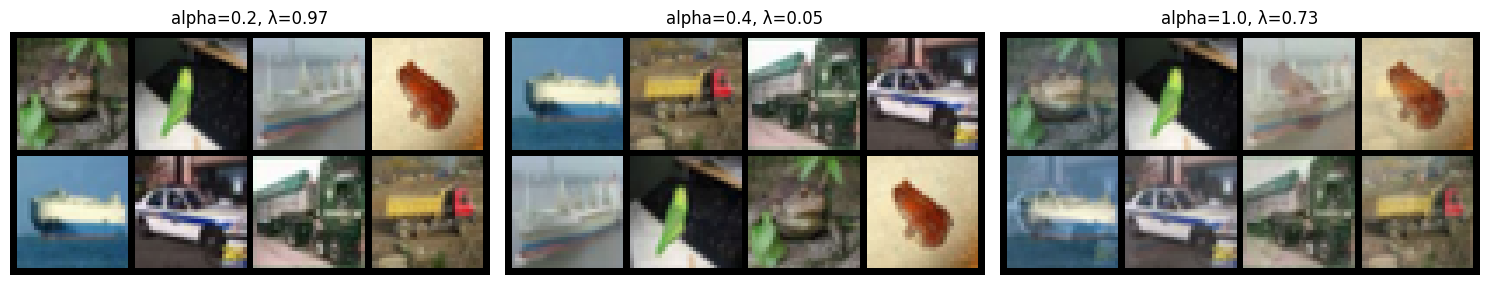

In [ ]:
def visualize_mixup_subplot(alphas=[0.2, 0.4, 1.0]):
    loader, _ = get_loaders(transform_raw, batch_size=8)
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)

    fig, axes = plt.subplots(1, len(alphas), figsize=(15, 4))

    if len(alphas) == 1:
        axes = [axes]

    for ax, alpha in zip(axes, alphas):
        mixed_x, _, _, lam = mixup_data(x, y, alpha)
        mixed_x = mixed_x.cpu()

        grid = torchvision.utils.make_grid(
            mixed_x[:8], nrow=4, normalize=True
        )

        ax.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
        ax.set_title(f"alpha={alpha}, λ={lam:.2f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

visualize_mixup_subplot([0.2, 0.4, 1.0])

# Problem 2

In [ ]:
class SimpleCNN_Manifold(nn.Module):
    def __init__(self):
        super().__init__()

        # ----- block 1 -----
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # ----- block 2 -----
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # ----- classifier -----
        self.fc1 = nn.Sequential(
            nn.Linear(64*8*8, 128),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x, mix_layer=None, lam=None, index=None):
        # layer 0: input mix already handled outside

        x = self.conv1(x)
        if mix_layer == 1:
            x = lam * x + (1 - lam) * x[index]

        x = self.conv2(x)
        if mix_layer == 2:
            x = lam * x + (1 - lam) * x[index]

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        if mix_layer == 3:
            x = lam * x + (1 - lam) * x[index]

        x = self.fc2(x)
        return x

In [ ]:
def manifold_mixup_data(x, y, alpha=1.0):
    if alpha > 0:
        lam = Beta(alpha, alpha).sample().item()
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)

    return x, y, index, lam

In [ ]:
def train_manifold(alpha=0.4, epochs=20, mix_layer_choice="random"):
    trainloader, testloader = get_loaders(transform_aug)

    model = SimpleCNN_Manifold().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for x, y in trainloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            # choose layer
            if mix_layer_choice == "random":
                mix_layer = random.choice([1, 2, 3])
            else:
                mix_layer = mix_layer_choice

            x, y_a, index, lam = manifold_mixup_data(x, y, alpha)

            outputs = model(x, mix_layer=mix_layer,
                            lam=lam, index=index)

            loss = lam * criterion(outputs, y_a) + \
                   (1 - lam) * criterion(outputs, y_a[index])

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(trainloader)
        val_loss, val_acc = evaluate(model, testloader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"MANIFOLD Epoch {epoch+1}/{epochs} "
              f"Loss: {train_loss:.4f} Acc: {val_acc:.2f}%")

    return model, train_losses, val_losses, val_acc

In [ ]:
results_manifold = {}

print("=== Random layer ===")
results_manifold["random"] = train_manifold(alpha=0.4)

print("=== Mix at layer 1 ===")
results_manifold["layer1"] = train_manifold(alpha=0.4, mix_layer_choice=1)

print("=== Mix at layer 2 ===")
results_manifold["layer2"] = train_manifold(alpha=0.4, mix_layer_choice=2)

print("=== Mix at layer 3 ===")
results_manifold["layer3"] = train_manifold(alpha=0.4, mix_layer_choice=3)

=== Random layer ===
MANIFOLD Epoch 1/20 Loss: 1.7305 Acc: 58.33%
MANIFOLD Epoch 2/20 Loss: 1.4798 Acc: 63.10%
MANIFOLD Epoch 3/20 Loss: 1.3988 Acc: 68.18%
MANIFOLD Epoch 4/20 Loss: 1.3772 Acc: 69.86%
MANIFOLD Epoch 5/20 Loss: 1.3404 Acc: 67.07%
MANIFOLD Epoch 6/20 Loss: 1.3014 Acc: 69.52%
MANIFOLD Epoch 7/20 Loss: 1.2931 Acc: 72.78%
MANIFOLD Epoch 8/20 Loss: 1.2780 Acc: 71.28%
MANIFOLD Epoch 9/20 Loss: 1.2508 Acc: 72.85%
MANIFOLD Epoch 10/20 Loss: 1.2419 Acc: 73.88%
MANIFOLD Epoch 11/20 Loss: 1.1699 Acc: 75.17%
MANIFOLD Epoch 12/20 Loss: 1.2138 Acc: 75.19%
MANIFOLD Epoch 13/20 Loss: 1.2421 Acc: 74.16%
MANIFOLD Epoch 14/20 Loss: 1.2521 Acc: 76.72%
MANIFOLD Epoch 15/20 Loss: 1.1806 Acc: 77.08%
MANIFOLD Epoch 16/20 Loss: 1.1542 Acc: 76.67%
MANIFOLD Epoch 17/20 Loss: 1.1816 Acc: 77.33%
MANIFOLD Epoch 18/20 Loss: 1.1996 Acc: 77.82%
MANIFOLD Epoch 19/20 Loss: 1.1519 Acc: 76.49%
MANIFOLD Epoch 20/20 Loss: 1.0965 Acc: 77.80%
=== Mix at layer 1 ===
MANIFOLD Epoch 1/20 Loss: 1.7741 Acc: 54.33%


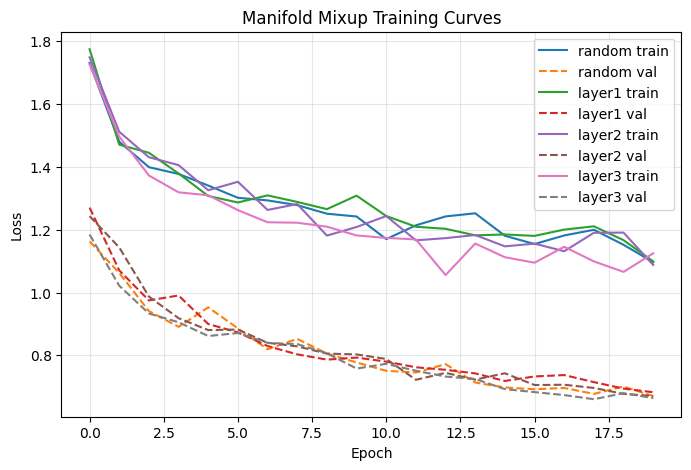

In [ ]:
plt.figure(figsize=(8,5))

for key in results_manifold:
    plt.plot(results_manifold[key][1], label=f"{key} train")
    plt.plot(results_manifold[key][2], '--', label=f"{key} val")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Manifold Mixup Training Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
results_manifold = {}

print("=== Random layer ===")
results_manifold["random"] = train_manifold(alpha=0.2)

print("=== Mix at layer 1 ===")
results_manifold["layer1"] = train_manifold(alpha=0.2, mix_layer_choice=1)

print("=== Mix at layer 2 ===")
results_manifold["layer2"] = train_manifold(alpha=0.2, mix_layer_choice=2)

print("=== Mix at layer 3 ===")
results_manifold["layer3"] = train_manifold(alpha=0.2, mix_layer_choice=3)

=== Random layer ===
MANIFOLD Epoch 1/20 Loss: 1.6719 Acc: 55.23%
MANIFOLD Epoch 2/20 Loss: 1.3894 Acc: 62.78%
MANIFOLD Epoch 3/20 Loss: 1.3038 Acc: 64.64%
MANIFOLD Epoch 4/20 Loss: 1.2137 Acc: 68.73%
MANIFOLD Epoch 5/20 Loss: 1.1824 Acc: 70.54%
MANIFOLD Epoch 6/20 Loss: 1.1628 Acc: 72.12%
MANIFOLD Epoch 7/20 Loss: 1.1341 Acc: 71.59%
MANIFOLD Epoch 8/20 Loss: 1.1096 Acc: 72.33%
MANIFOLD Epoch 9/20 Loss: 1.1058 Acc: 73.40%
MANIFOLD Epoch 10/20 Loss: 1.1224 Acc: 73.18%
MANIFOLD Epoch 11/20 Loss: 1.0808 Acc: 76.03%
MANIFOLD Epoch 12/20 Loss: 1.0415 Acc: 75.05%
MANIFOLD Epoch 13/20 Loss: 1.0066 Acc: 76.80%
MANIFOLD Epoch 14/20 Loss: 1.0887 Acc: 75.04%
MANIFOLD Epoch 15/20 Loss: 1.0963 Acc: 78.09%
MANIFOLD Epoch 16/20 Loss: 1.0061 Acc: 77.91%
MANIFOLD Epoch 17/20 Loss: 0.9766 Acc: 78.06%
MANIFOLD Epoch 18/20 Loss: 1.0325 Acc: 77.06%
MANIFOLD Epoch 19/20 Loss: 0.9600 Acc: 76.58%
MANIFOLD Epoch 20/20 Loss: 0.9847 Acc: 77.96%
=== Mix at layer 1 ===
MANIFOLD Epoch 1/20 Loss: 1.6344 Acc: 58.92%


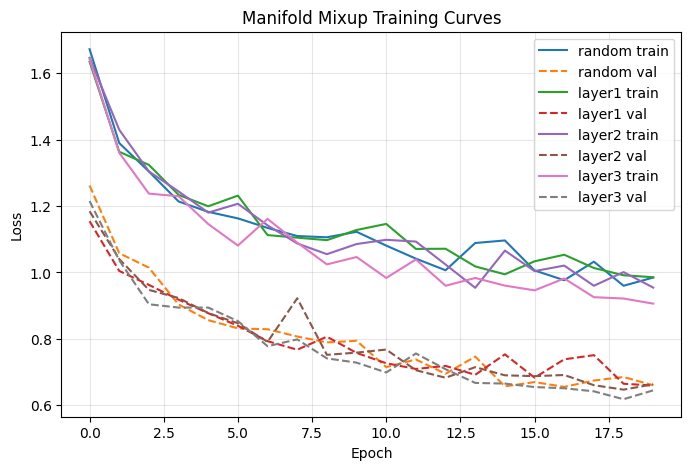

In [ ]:
plt.figure(figsize=(8,5))

for key in results_manifold:
    plt.plot(results_manifold[key][1], label=f"{key} train")
    plt.plot(results_manifold[key][2], '--', label=f"{key} val")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Manifold Mixup Training Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.manifold import TSNE

def visualize_features(model, loader, num_samples=500):
    model.eval()
    feats, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            f = model.conv1(x)
            f = model.conv2(f)
            f = f.view(f.size(0), -1)

            feats.append(f.cpu())
            labels.append(y)

            if len(torch.cat(feats)) > num_samples:
                break

    feats = torch.cat(feats)[:num_samples].numpy()
    labels = torch.cat(labels)[:num_samples].numpy()

    tsne = TSNE(n_components=2, random_state=42)
    emb = tsne.fit_transform(feats)

    plt.figure(figsize=(6,5))
    plt.scatter(emb[:,0], emb[:,1], c=labels, s=5)
    plt.title("Feature Space Visualization (t-SNE)")
    plt.show()

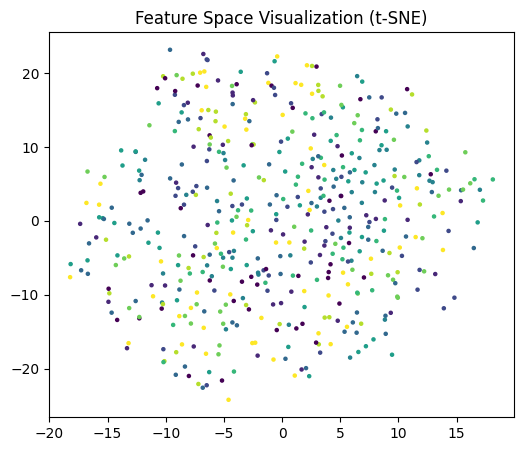

In [ ]:
model = SimpleCNN_Manifold().to(device)
trainloader, testloader = get_loaders(transform_aug)
visualize_features(model , trainloader)

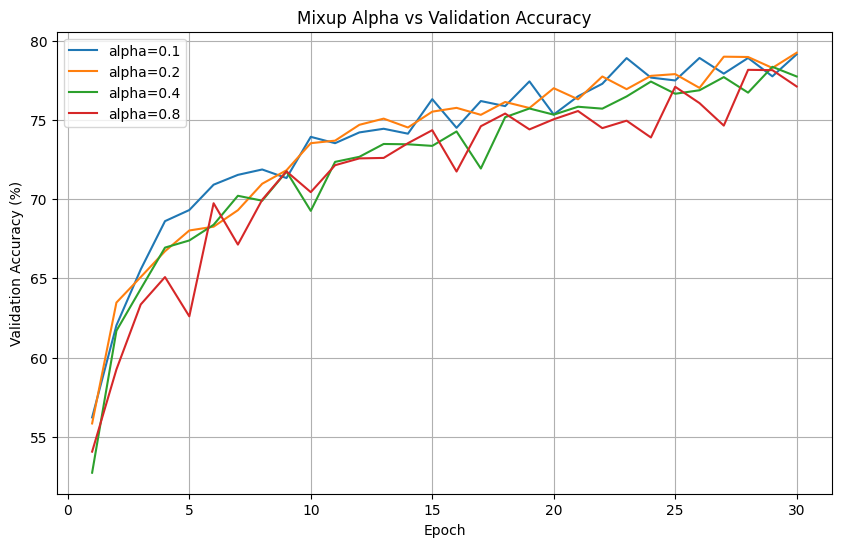

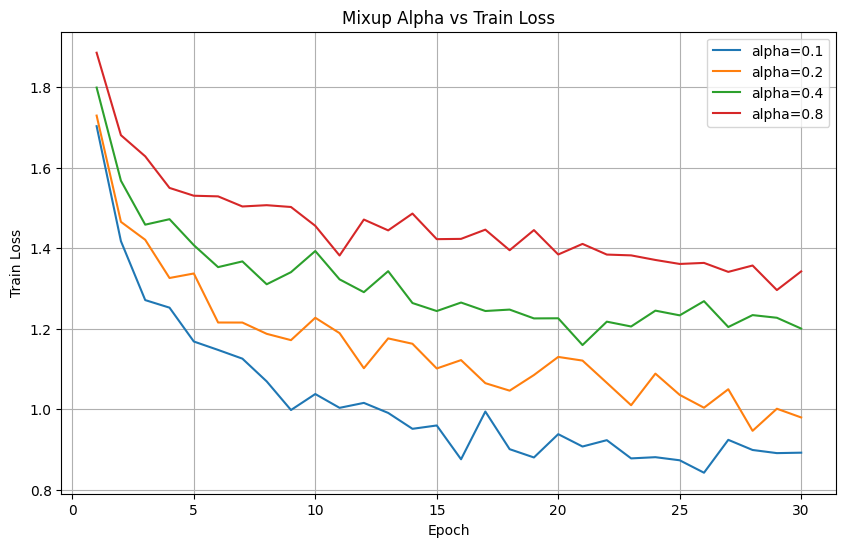

In [ ]:
import matplotlib.pyplot as plt

# ---- paste your dict above this line ----
# mixup_logs = {...}

plt.figure(figsize=(10, 6))

for alpha, logs in mixup_logs.items():
    epochs = [entry["epoch"] for entry in logs]
    val_accs = [entry["val_acc"] for entry in logs]
    plt.plot(epochs, val_accs, label=f"alpha={alpha}")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Mixup Alpha vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(10, 6))

for alpha, logs in mixup_logs.items():
    epochs = [entry["epoch"] for entry in logs]
    losses = [entry["train_loss"] for entry in logs]
    plt.plot(epochs, losses, label=f"alpha={alpha}")

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Mixup Alpha vs Train Loss")
plt.legend()
plt.grid(True)

plt.show()

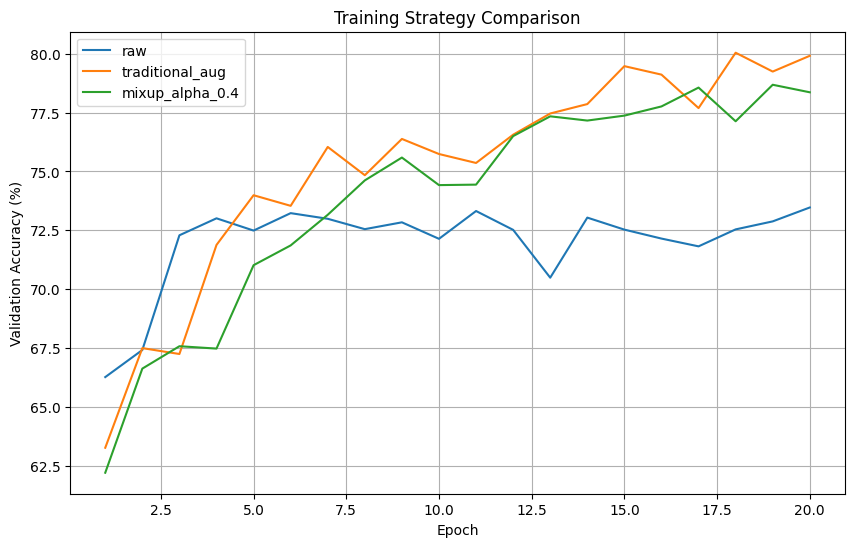

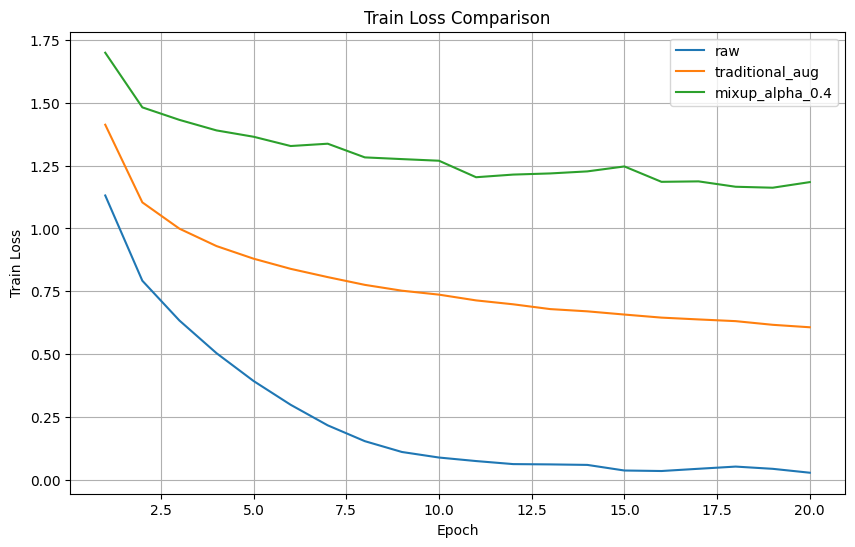

In [ ]:
training_logs = {
    "raw": [
        {"epoch": 1, "train_loss": 1.1312, "val_acc": 66.27},
        {"epoch": 2, "train_loss": 0.7922, "val_acc": 67.42},
        {"epoch": 3, "train_loss": 0.6339, "val_acc": 72.29},
        {"epoch": 4, "train_loss": 0.5040, "val_acc": 73.01},
        {"epoch": 5, "train_loss": 0.3933, "val_acc": 72.49},
        {"epoch": 6, "train_loss": 0.2987, "val_acc": 73.23},
        {"epoch": 7, "train_loss": 0.2169, "val_acc": 72.99},
        {"epoch": 8, "train_loss": 0.1540, "val_acc": 72.55},
        {"epoch": 9, "train_loss": 0.1110, "val_acc": 72.84},
        {"epoch": 10, "train_loss": 0.0889, "val_acc": 72.14},
        {"epoch": 11, "train_loss": 0.0749, "val_acc": 73.32},
        {"epoch": 12, "train_loss": 0.0628, "val_acc": 72.52},
        {"epoch": 13, "train_loss": 0.0616, "val_acc": 70.49},
        {"epoch": 14, "train_loss": 0.0596, "val_acc": 73.04},
        {"epoch": 15, "train_loss": 0.0373, "val_acc": 72.53},
        {"epoch": 16, "train_loss": 0.0353, "val_acc": 72.15},
        {"epoch": 17, "train_loss": 0.0442, "val_acc": 71.82},
        {"epoch": 18, "train_loss": 0.0529, "val_acc": 72.54},
        {"epoch": 19, "train_loss": 0.0440, "val_acc": 72.88},
        {"epoch": 20, "train_loss": 0.0285, "val_acc": 73.47},
    ],

    "traditional_aug": [
        {"epoch": 1, "train_loss": 1.4126, "val_acc": 63.27},
        {"epoch": 2, "train_loss": 1.1038, "val_acc": 67.50},
        {"epoch": 3, "train_loss": 0.9992, "val_acc": 67.25},
        {"epoch": 4, "train_loss": 0.9300, "val_acc": 71.88},
        {"epoch": 5, "train_loss": 0.8798, "val_acc": 73.99},
        {"epoch": 6, "train_loss": 0.8394, "val_acc": 73.54},
        {"epoch": 7, "train_loss": 0.8065, "val_acc": 76.04},
        {"epoch": 8, "train_loss": 0.7757, "val_acc": 74.84},
        {"epoch": 9, "train_loss": 0.7525, "val_acc": 76.38},
        {"epoch": 10, "train_loss": 0.7368, "val_acc": 75.74},
        {"epoch": 11, "train_loss": 0.7139, "val_acc": 75.36},
        {"epoch": 12, "train_loss": 0.6984, "val_acc": 76.56},
        {"epoch": 13, "train_loss": 0.6793, "val_acc": 77.46},
        {"epoch": 14, "train_loss": 0.6704, "val_acc": 77.86},
        {"epoch": 15, "train_loss": 0.6576, "val_acc": 79.47},
        {"epoch": 16, "train_loss": 0.6454, "val_acc": 79.11},
        {"epoch": 17, "train_loss": 0.6382, "val_acc": 77.69},
        {"epoch": 18, "train_loss": 0.6314, "val_acc": 80.04},
        {"epoch": 19, "train_loss": 0.6168, "val_acc": 79.24},
        {"epoch": 20, "train_loss": 0.6070, "val_acc": 79.91},
    ],

    "mixup_alpha_0.4": [
        {"epoch": 1, "train_loss": 1.6990, "val_acc": 62.21},
        {"epoch": 2, "train_loss": 1.4817, "val_acc": 66.63},
        {"epoch": 3, "train_loss": 1.4319, "val_acc": 67.58},
        {"epoch": 4, "train_loss": 1.3900, "val_acc": 67.48},
        {"epoch": 5, "train_loss": 1.3648, "val_acc": 71.02},
        {"epoch": 6, "train_loss": 1.3279, "val_acc": 71.86},
        {"epoch": 7, "train_loss": 1.3371, "val_acc": 73.16},
        {"epoch": 8, "train_loss": 1.2827, "val_acc": 74.62},
        {"epoch": 9, "train_loss": 1.2759, "val_acc": 75.59},
        {"epoch": 10, "train_loss": 1.2694, "val_acc": 74.42},
        {"epoch": 11, "train_loss": 1.2038, "val_acc": 74.44},
        {"epoch": 12, "train_loss": 1.2143, "val_acc": 76.50},
        {"epoch": 13, "train_loss": 1.2189, "val_acc": 77.34},
        {"epoch": 14, "train_loss": 1.2270, "val_acc": 77.16},
        {"epoch": 15, "train_loss": 1.2467, "val_acc": 77.37},
        {"epoch": 16, "train_loss": 1.1855, "val_acc": 77.76},
        {"epoch": 17, "train_loss": 1.1873, "val_acc": 78.56},
        {"epoch": 18, "train_loss": 1.1659, "val_acc": 77.13},
        {"epoch": 19, "train_loss": 1.1621, "val_acc": 78.68},
        {"epoch": 20, "train_loss": 1.1844, "val_acc": 78.36},
    ],
}

import matplotlib.pyplot as plt

# ---- paste your training_logs dict above this line ----

plt.figure(figsize=(10, 6))

for method, logs in training_logs.items():
    epochs = [x["epoch"] for x in logs]
    val_acc = [x["val_acc"] for x in logs]
    plt.plot(epochs, val_acc, label=method)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Training Strategy Comparison")
plt.legend()
plt.grid(True)

plt.show()


plt.figure(figsize=(10, 6))

for method, logs in training_logs.items():
    epochs = [x["epoch"] for x in logs]
    losses = [x["train_loss"] for x in logs]
    plt.plot(epochs, losses, label=method)

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Train Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

raw: best_val_acc=73.47% at epoch 20
traditional_aug: best_val_acc=80.04% at epoch 18
mixup_alpha_0.4: best_val_acc=78.68% at epoch 19
